# 20D O1 brute-force three-stage depth policies

Analysis of all 64 schedules on the 20-dimensional O1 problem over depths `{5, 10, 15, 20}` for stages 1–250, 251–600, and 601–1000. The other RF hyperparameters use SMAC defaults. Rankings use final simple regret (lower is better). Across-seed top policies are selected on these same five seeds, so their comparison is exploratory.

In [1]:
from __future__ import annotations
import itertools, json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import t

DEPTHS = (5, 10, 15, 20)
SEEDS = tuple(range(5))
STAGES = ('trials 1–250', 'trials 251–600', 'trials 601–1000')
EXPECTED = set(itertools.product(DEPTHS, repeat=3))
candidates = [Path.cwd(), Path.cwd() / 'experiments/synthaticBench/o1_deterministic/depth_policies/04_03_20d']
HERE = next((p for p in candidates if (p / 'o1_depth_runner.py').exists()), None)
if HERE is None: raise FileNotFoundError('Run from the notebook directory or repository root.')
OUTPUT = HERE / 'smac_output'
print(HERE.resolve())

/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/04_03_20d


## Load, validate, and report completeness

In [2]:
rows, curves = [], {}
for family in ('policies', 'fixed'):
    for path in sorted((OUTPUT / family).rglob('trajectory.json')):
        data = json.loads(path.read_text())
        schedule = tuple(map(int, data['depth_schedule']))
        best = np.asarray(data['best_regret'], float)
        key = (family, data['policy'], int(data['smac_seed']))
        if key in curves: raise ValueError(f'Duplicate trajectory: {key}')
        curves[key] = best
        rows.append({
            'family': family, 'policy': data['policy'], 'seed': int(data['smac_seed']),
            'd1': schedule[0], 'd2': schedule[1], 'd3': schedule[2], 'schedule': schedule,
            'final_regret': float(best[-1]), 'mean_regret': float(best.mean()),
            'log_auc': float(np.log10(np.maximum(best, 1e-300)).mean()),
            'n_trials': int(data['n_trials']), 'problem_seed': int(data['problem_seed']),
            'pythonhashseed': str(data['pythonhashseed']),
            'dimension': int(data['dimension']),
            'min_samples_leaf': int(data['min_samples_leaf']),
            'min_samples_split': int(data['min_samples_split']), 'path': path,
        })
results = pd.DataFrame(rows)
if results.empty:
    raise FileNotFoundError(f'No results below {OUTPUT}; jobs are unfinished or failed.')
bad = results.query("n_trials != 1000 or problem_seed != 52 or dimension != 20 or pythonhashseed != '12345' or min_samples_leaf != 3 or min_samples_split != 3")
if not bad.empty: display(bad); raise ValueError('Incompatible trajectory metadata.')
dynamic = results.query("family == 'policies'").copy()
fixed = results.query("family == 'fixed'").copy()
counts = dynamic.groupby('policy')['seed'].nunique()
complete_names = set(counts[counts == 5].index)
fixed_counts = fixed.groupby('policy')['seed'].nunique() if not fixed.empty else pd.Series(dtype=int)
complete_fixed = set(fixed_counts[fixed_counts == 5].index)
print(f'Loaded {len(dynamic)}/320 dynamic and {len(fixed)}/20 fixed trajectories.')
print(f'Complete schedules: {len(complete_names)}/64; complete fixed baselines: {len(complete_fixed)}/4')
print('Missing schedules:', sorted(EXPECTED - set(dynamic['schedule'])))
display(counts.value_counts().sort_index().rename_axis('completed seeds').to_frame('policies'))

Loaded 320/320 dynamic and 20/20 fixed trajectories.
Complete schedules: 64/64; complete fixed baselines: 4/4
Missing schedules: []


,policies
completed seeds,
5,64


## Top 5 and top 10 policies for each seed

In [3]:
def top_for_seed(seed, n):
    table = dynamic.query('seed == @seed').sort_values(['final_regret', 'mean_regret', 'policy']).head(n)
    table = table[['policy', 'd1', 'd2', 'd3', 'final_regret', 'mean_regret', 'log_auc']].reset_index(drop=True)
    table.index = np.arange(1, len(table) + 1); table.index.name = 'rank'
    return table
for seed in SEEDS:
    print(f'\nSeed {seed}: top 5'); display(top_for_seed(seed, 5))
    print(f'Seed {seed}: top 10'); display(top_for_seed(seed, 10))


Seed 0: top 5


,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_5_5_20,5,5,20,35833.278861,106422.138558,4.938819
2,depth_policy_5_15_10,5,15,10,36861.872133,120066.342070,5.021725
3,depth_policy_10_10_20,10,10,20,39444.698479,115496.172721,4.973572
4,depth_policy_15_10_20,15,10,20,39444.698479,115496.172721,4.973572
5,depth_policy_20_10_20,20,10,20,39444.698479,115496.172721,4.973572


Seed 0: top 10


,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_5_5_20,5,5,20,35833.278861,106422.138558,4.938819
2,depth_policy_5_15_10,5,15,10,36861.872133,120066.342070,5.021725
3,depth_policy_10_10_20,10,10,20,39444.698479,115496.172721,4.973572
4,depth_policy_15_10_20,15,10,20,39444.698479,115496.172721,4.973572
5,depth_policy_20_10_20,20,10,20,39444.698479,115496.172721,4.973572
6,depth_policy_10_10_15,10,10,15,46350.203516,116467.557273,4.982628
7,depth_policy_15_10_15,15,10,15,46350.203516,116467.557273,4.982628
8,depth_policy_20_10_15,20,10,15,46350.203516,116467.557273,4.982628
9,depth_policy_10_10_10,10,10,10,50238.623769,116241.323229,4.981213



Seed 1: top 5


...

,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_10_20_20,10,20,20,19586.592454,133080.628088,4.950722
2,depth_policy_10_20_15,10,20,15,26204.742205,134597.747709,4.983296
3,depth_policy_10_20_10,10,20,10,31211.698647,139572.281004,5.028429
4,depth_policy_10_15_15,10,15,15,38181.385226,140310.198820,5.033954
5,depth_policy_5_5_15,5,5,15,38307.255458,173620.445230,5.139376
6,depth_policy_10_10_10,10,10,10,40697.241315,135724.051460,4.990614
7,depth_policy_10_10_15,10,10,15,41119.221935,137910.105090,5.011632
8,depth_policy_10_15_10,10,15,10,41154.488867,139161.496608,5.022280
9,depth_policy_15_15_15,15,15,15,41549.681987,142440.838419,5.034218



Seed 4: top 5


,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_5_10_15,5,10,15,28522.721281,117270.466582,4.961896
2,depth_policy_15_10_15,15,10,15,29723.295258,108283.365816,4.936254
3,depth_policy_20_10_15,20,10,15,29723.295258,108283.365816,4.936254
4,depth_policy_15_10_10,15,10,10,30265.858459,108584.731621,4.935681
5,depth_policy_20_10_10,20,10,10,30265.858459,108584.731621,4.935681


Seed 4: top 10


,policy,d1,d2,d3,final_regret,mean_regret,log_auc
rank,,,,,,,
1,depth_policy_5_10_15,5,10,15,28522.721281,117270.466582,4.961896
2,depth_policy_15_10_15,15,10,15,29723.295258,108283.365816,4.936254
3,depth_policy_20_10_15,20,10,15,29723.295258,108283.365816,4.936254
4,depth_policy_15_10_10,15,10,10,30265.858459,108584.731621,4.935681
5,depth_policy_20_10_10,20,10,10,30265.858459,108584.731621,4.935681
6,depth_policy_5_10_20,5,10,20,30696.134038,113663.653149,4.923127
7,depth_policy_15_10_20,15,10,20,31398.591538,108111.705371,4.934762
8,depth_policy_20_10_20,20,10,20,31398.591538,108111.705371,4.934762
9,depth_policy_15_20_20,15,20,20,33192.300937,112192.496755,4.956387


## Per-seed depth frequencies among the top 5 and top 10

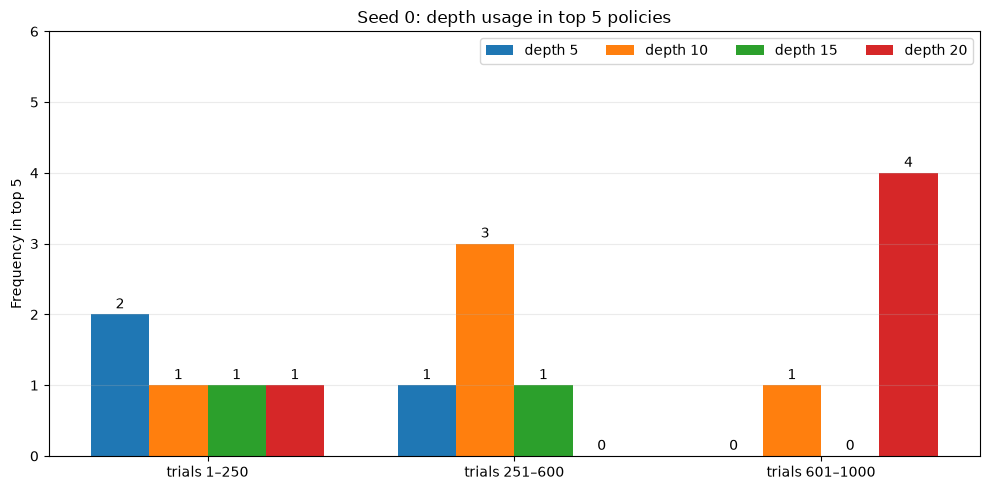

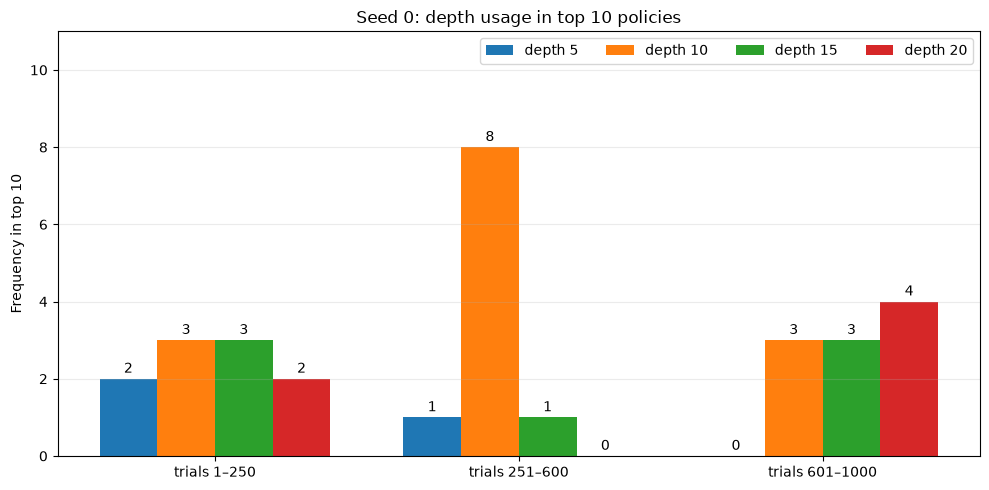

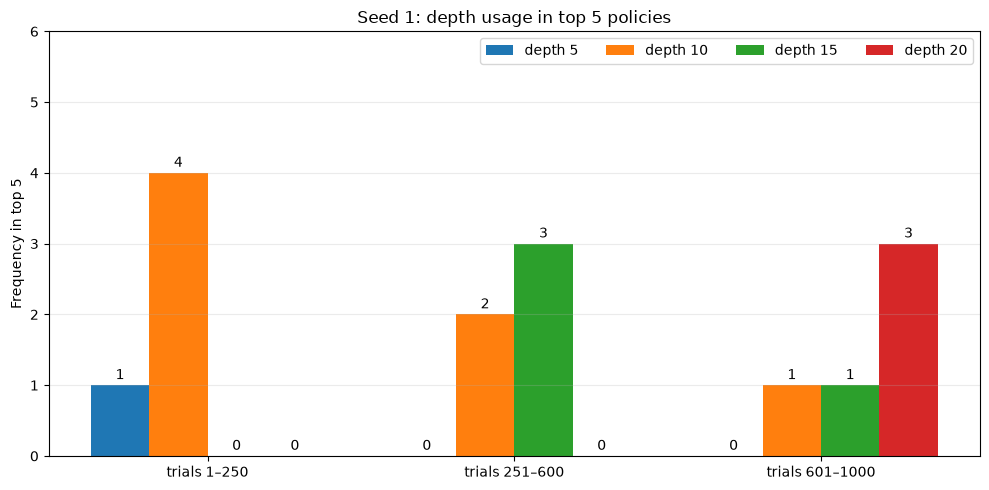

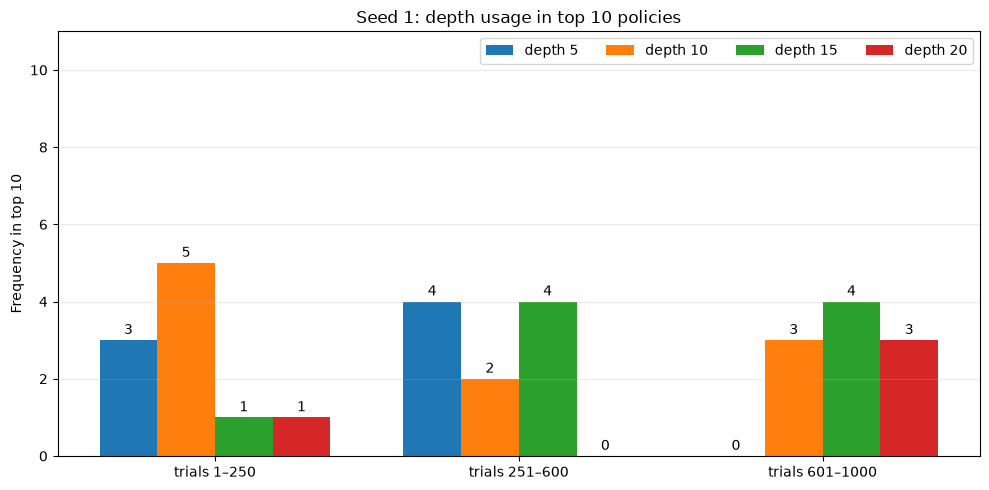

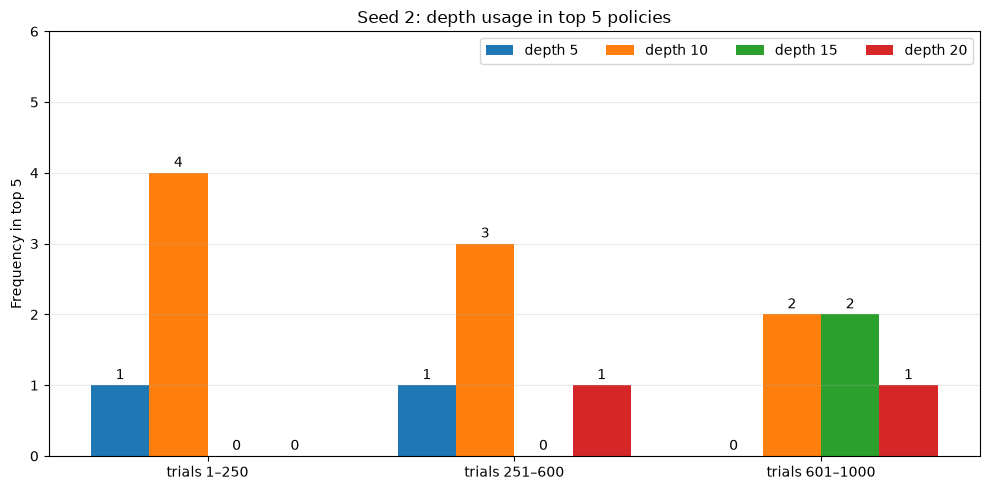

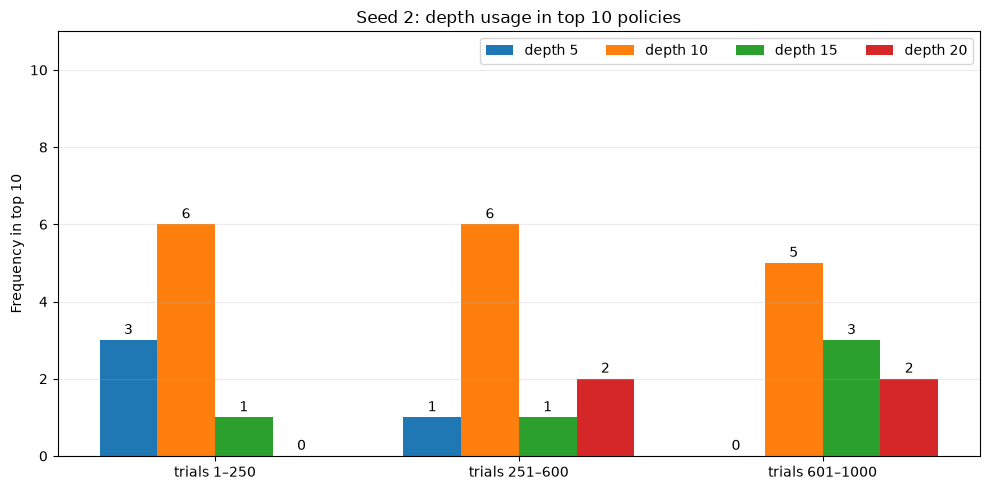

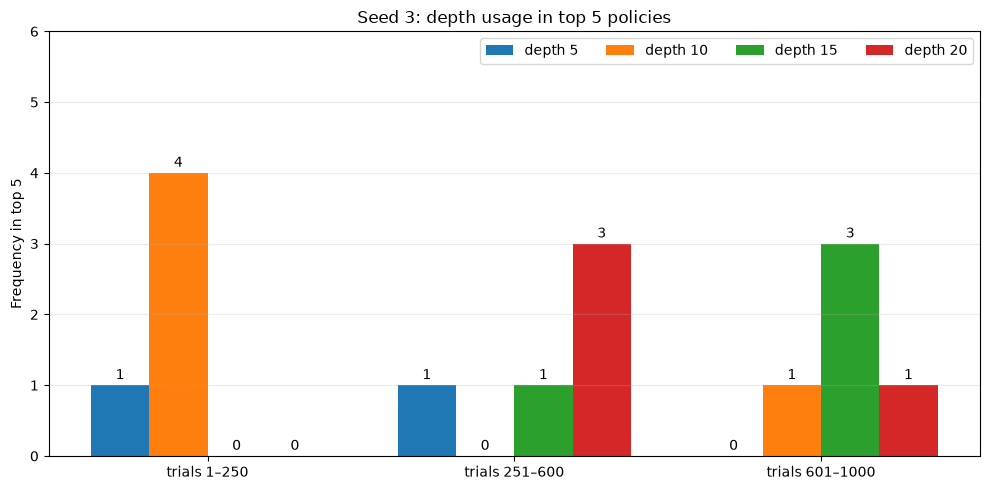

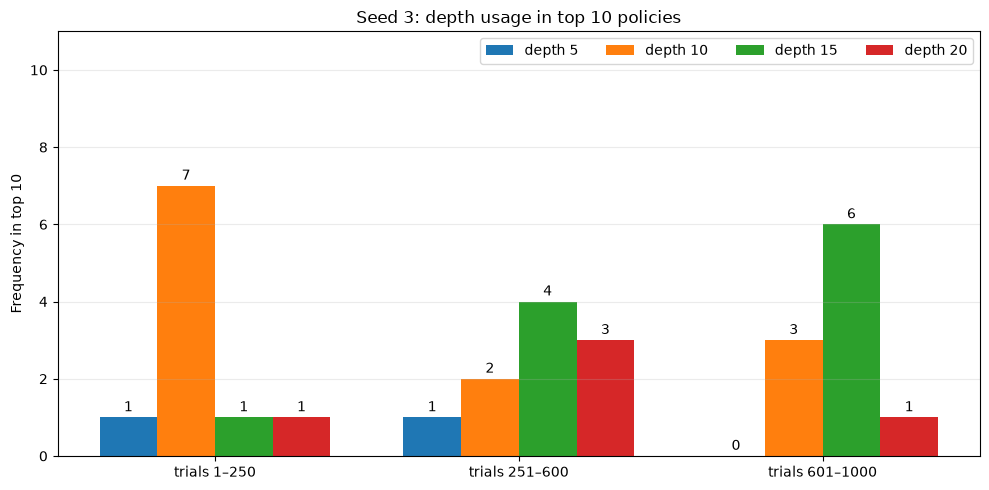

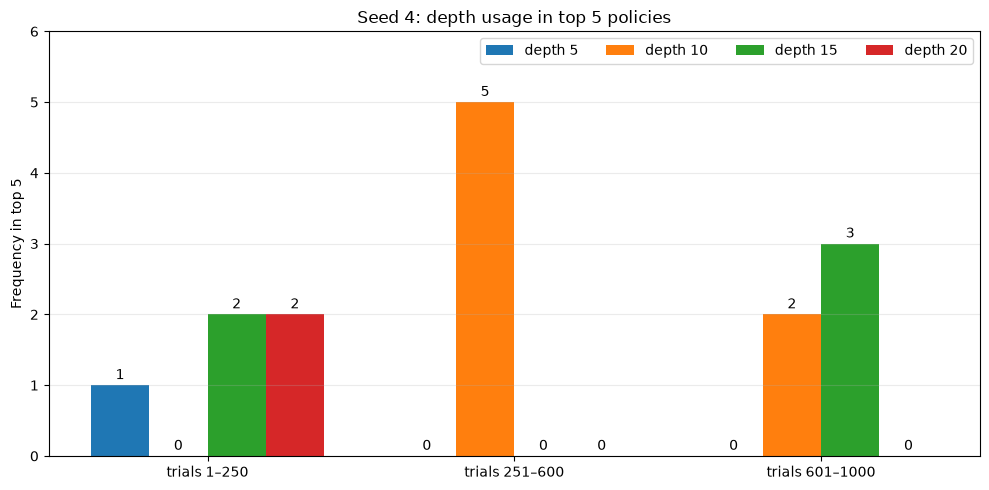

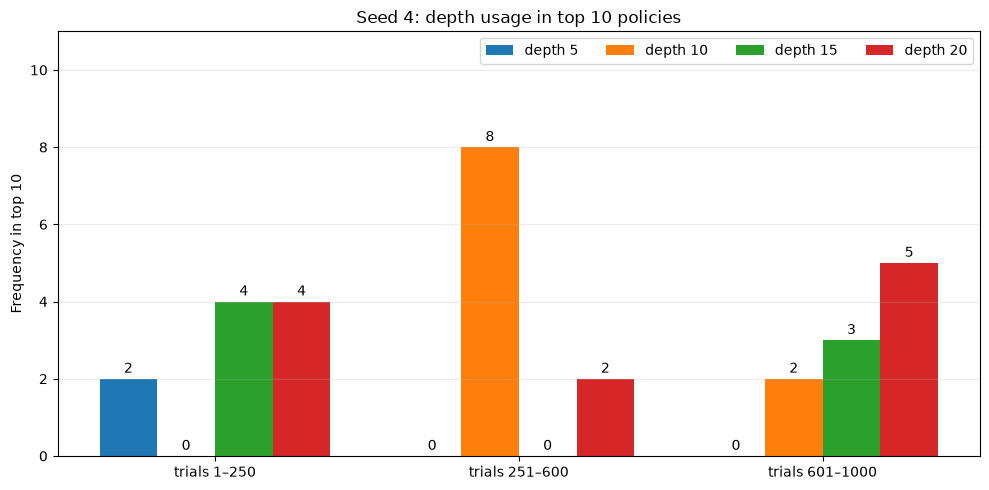

In [4]:
def frequency_plot(seed, n):
    selected = top_for_seed(seed, n); x = np.arange(3); width = 0.19
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, depth in enumerate(DEPTHS):
        values = [int((selected[f'd{stage}'] == depth).sum()) for stage in (1, 2, 3)]
        bars = ax.bar(x + (i - 1.5) * width, values, width, label=f'depth {depth}')
        ax.bar_label(bars, padding=2)
    ax.set_xticks(x, STAGES); ax.set_ylim(0, n + 1); ax.set_ylabel(f'Frequency in top {n}')
    ax.set_title(f'Seed {seed}: depth usage in top {n} policies'); ax.legend(ncol=4); ax.grid(axis='y', alpha=.25)
    plt.tight_layout(); plt.show()
for seed in SEEDS:
    frequency_plot(seed, 5); frequency_plot(seed, 10)

## Top five policies across seeds

In [5]:
complete = dynamic[dynamic.policy.isin(complete_names)].copy()
summary = (complete.groupby(['policy', 'd1', 'd2', 'd3'], as_index=False)
    .agg(mean_final=('final_regret','mean'), std_final=('final_regret','std'), median_final=('final_regret','median'), mean_regret=('mean_regret','mean'), mean_log_auc=('log_auc','mean'), seeds=('seed','nunique'))
    .sort_values(['mean_final','mean_regret','policy']).reset_index(drop=True))
summary.index = np.arange(1, len(summary)+1); summary.index.name = 'rank'
top5 = summary.head(5).copy(); display(top5)
print('Top 10 by full-trajectory log-regret AUC:')
display(summary.sort_values(['mean_log_auc','mean_final']).head(10))

,policy,d1,d2,d3,mean_final,std_final,median_final,mean_regret,mean_log_auc,seeds
rank,,,,,,,,,,
1,depth_policy_10_10_20,10,10,20,44721.278359,9771.466224,41178.209024,126911.221427,5.007627,5
2,depth_policy_10_20_15,10,20,15,44866.796780,16260.840788,40624.283016,129628.403232,5.022621,5
3,depth_policy_5_10_15,5,10,15,48376.001429,14006.379737,51429.687662,133688.402331,5.028583,5
4,depth_policy_10_10_15,10,10,15,48819.174363,12705.406250,46350.203516,127846.584103,5.016084,5
5,depth_policy_5_10_20,5,10,20,49665.495291,17340.185230,48030.256633,134310.995131,5.028057,5


Top 10 by full-trajectory log-regret AUC:


,policy,d1,d2,d3,mean_final,std_final,median_final,mean_regret,mean_log_auc,seeds
rank,,,,,,,,,,
1,depth_policy_10_10_20,10,10,20,44721.278359,9771.466224,41178.209024,126911.221427,5.007627,5
18,depth_policy_10_10_10,10,10,10,53068.909332,16545.154352,50238.623769,127906.486801,5.012401,5
4,depth_policy_10_10_15,10,10,15,48819.174363,12705.406250,46350.203516,127846.584103,5.016084,5
2,depth_policy_10_20_15,10,20,15,44866.796780,16260.840788,40624.283016,129628.403232,5.022621,5
5,depth_policy_5_10_20,5,10,20,49665.495291,17340.185230,48030.256633,134310.995131,5.028057,5
26,depth_policy_5_10_10,5,10,10,56119.907373,14581.624347,60339.271736,133832.196041,5.028144,5
3,depth_policy_5_10_15,5,10,15,48376.001429,14006.379737,51429.687662,133688.402331,5.028583,5
6,depth_policy_10_20_20,10,20,20,50167.904574,19317.974360,53964.491264,130987.923709,5.030112,5
16,depth_policy_10_15_15,10,15,15,52958.863738,11176.240635,52402.383398,130687.236835,5.036116,5


## Top five versus fixed depths

Pointwise 95% Student-t confidence intervals across paired seeds, followed by final-regret boxplots. These cells require all four fixed baselines.

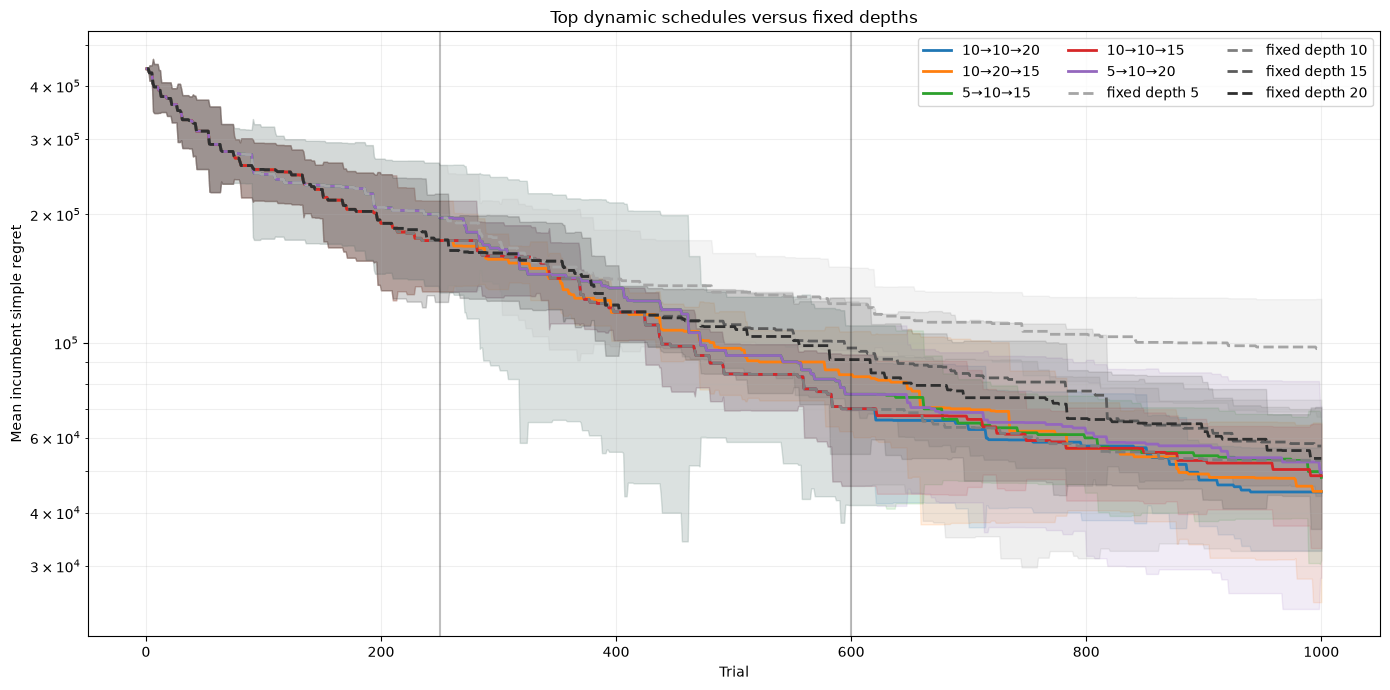

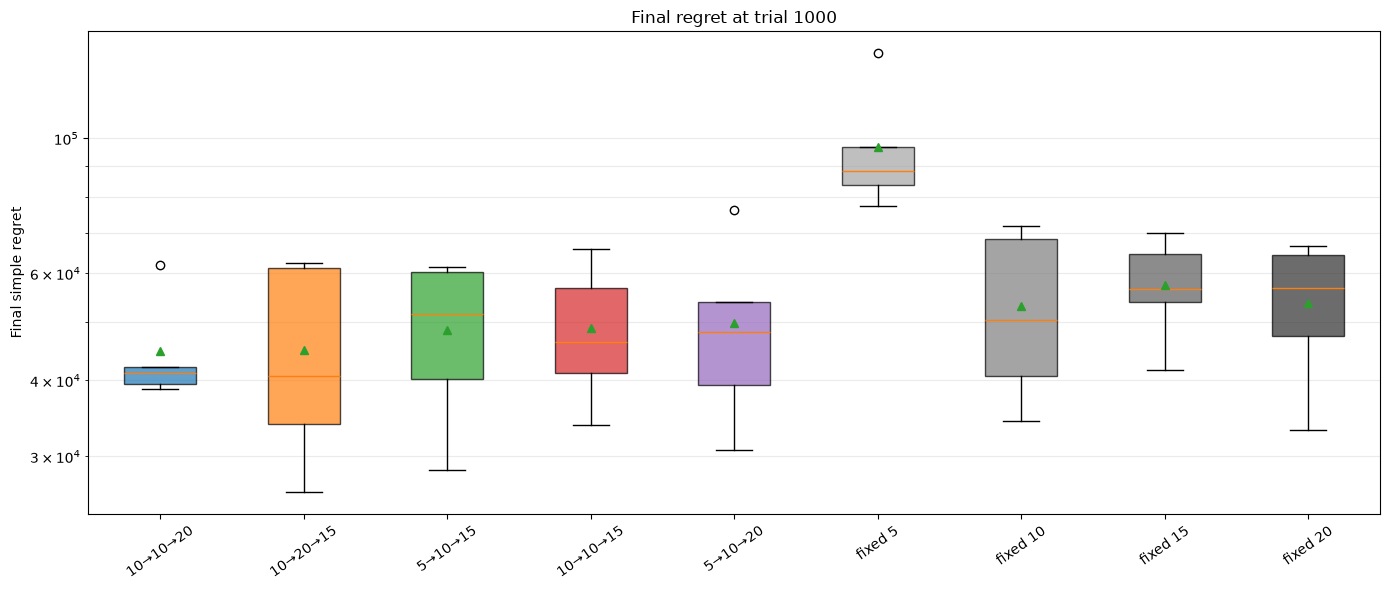

In [6]:
if len(complete_fixed) != 4: raise ValueError('Wait for all four fixed baselines to complete.')
policies = [('policies', p) for p in top5.policy] + [('fixed', f'fixed_depth_{d}') for d in DEPTHS]
def matrix(family, policy): return np.vstack([curves[(family, policy, seed)] for seed in SEEDS])
colors = list(plt.cm.tab10(np.linspace(0,.4,5))) + list(plt.cm.Greys(np.linspace(.45,.85,4)))
fig, ax = plt.subplots(figsize=(14,7))
for i, (family, policy) in enumerate(policies):
    m = matrix(family, policy); mean=m.mean(0); sem=m.std(0,ddof=1)/np.sqrt(5); margin=t.ppf(.975,4)*sem; x=np.arange(1,1001)
    label = policy.replace('depth_policy_','').replace('_','→') if family=='policies' else policy.replace('_',' ')
    ax.plot(x, np.maximum(mean,1e-300), color=colors[i], ls='-' if family=='policies' else '--', lw=2, label=label)
    ax.fill_between(x, np.maximum(mean-margin,1e-300), np.maximum(mean+margin,1e-300), color=colors[i], alpha=.12)
for boundary in (250,600): ax.axvline(boundary,color='black',alpha=.25)
ax.set_yscale('log'); ax.set_xlabel('Trial'); ax.set_ylabel('Mean incumbent simple regret'); ax.set_title('Top dynamic schedules versus fixed depths'); ax.grid(alpha=.2,which='both'); ax.legend(ncol=3)
plt.tight_layout(); plt.show()

values=[matrix(f,p)[:,-1] for f,p in policies]
labels=[p.replace('depth_policy_','').replace('_','→') if f=='policies' else p.replace('fixed_depth_','fixed ') for f,p in policies]
fig,ax=plt.subplots(figsize=(14,6)); boxes=ax.boxplot(values,tick_labels=labels,showmeans=True,patch_artist=True)
for box,color in zip(boxes['boxes'],colors): box.set_facecolor(color); box.set_alpha(.7)
ax.set_yscale('log'); ax.set_ylabel('Final simple regret'); ax.set_title('Final regret at trial 1000'); ax.tick_params(axis='x',rotation=35); ax.grid(axis='y',alpha=.25,which='both')
plt.tight_layout(); plt.show()

## Additional diagnostics: policy landscape and constant-schedule reproducibility

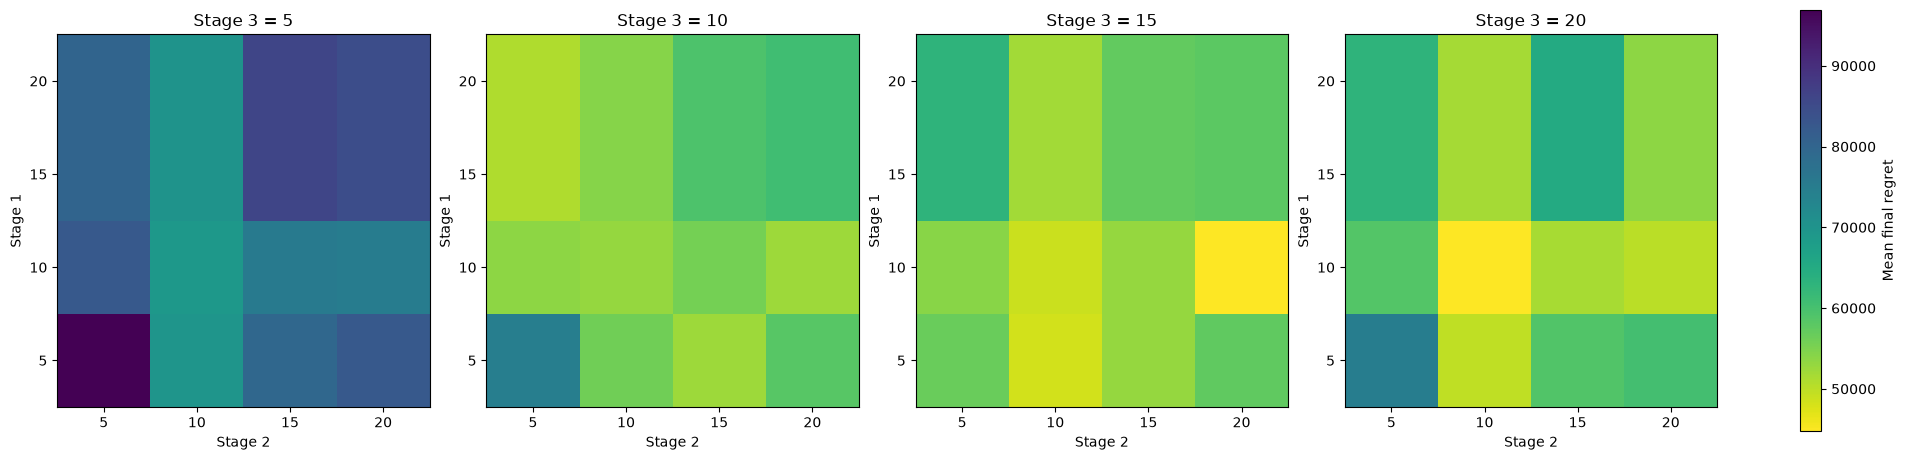

,depth,seed,identical,first_difference
0,5,0,True,None
1,5,1,True,None
2,5,2,True,None
3,5,3,True,None
4,5,4,True,None
5,10,0,True,None
6,10,1,True,None
7,10,2,True,None
8,10,3,True,None
9,10,4,True,None


Identical: 20/20


In [7]:
fig,axes=plt.subplots(1,4,figsize=(19,4.5),constrained_layout=True); vmin=summary.mean_final.min(); vmax=summary.mean_final.max()
for ax,d3 in zip(axes,DEPTHS):
    pivot=summary.query('d3==@d3').pivot(index='d1',columns='d2',values='mean_final').reindex(index=DEPTHS,columns=DEPTHS)
    image=ax.imshow(pivot,origin='lower',cmap='viridis_r',vmin=vmin,vmax=vmax); ax.set_xticks(range(4),DEPTHS); ax.set_yticks(range(4),DEPTHS); ax.set_xlabel('Stage 2'); ax.set_ylabel('Stage 1'); ax.set_title(f'Stage 3 = {d3}')
fig.colorbar(image,ax=axes,label='Mean final regret'); plt.show()

checks=[]
for depth in DEPTHS:
    for seed in SEEDS:
        a=('policies',f'depth_policy_{depth}_{depth}_{depth}',seed); b=('fixed',f'fixed_depth_{depth}',seed)
        if a in curves and b in curves:
            different=np.flatnonzero(curves[a] != curves[b]); checks.append({'depth':depth,'seed':seed,'identical':len(different)==0,'first_difference':None if len(different)==0 else int(different[0]+1)})
reproducibility=pd.DataFrame(checks); display(reproducibility)
if not reproducibility.empty: print(f"Identical: {reproducibility.identical.sum()}/{len(reproducibility)}")

## Paired comparison of the selected best dynamic and best fixed policy

In [8]:
fixed_summary=fixed[fixed.policy.isin(complete_fixed)].groupby('policy',as_index=False).agg(mean_final=('final_regret','mean'),std_final=('final_regret','std')).sort_values('mean_final'); display(fixed_summary)
best_dynamic=top5.iloc[0].policy; best_fixed=fixed_summary.iloc[0].policy
paired=(dynamic.query('policy==@best_dynamic')[['seed','final_regret']].rename(columns={'final_regret':'dynamic'})
    .merge(fixed.query('policy==@best_fixed')[['seed','final_regret']].rename(columns={'final_regret':'fixed'}),on='seed',validate='one_to_one'))
paired['difference']=paired.dynamic-paired.fixed; paired['relative_percent']=100*(paired.dynamic/paired.fixed-1)
print('Dynamic:',best_dynamic,'Fixed:',best_fixed); display(paired)
print(f"Dynamic wins {(paired.difference<0).sum()}/{len(paired)} seeds; mean relative change {paired.relative_percent.mean():.2f}%")

,policy,mean_final,std_final
0,fixed_depth_10,53068.909332,16545.154352
2,fixed_depth_20,53609.571033,13672.849762
1,fixed_depth_15,57304.959736,10899.054892
3,fixed_depth_5,96927.565568,24005.306651


Dynamic: depth_policy_10_10_20 Fixed: fixed_depth_10


,seed,dynamic,fixed,difference,relative_percent
0,0,39444.698479,50238.623769,-10793.925289,-21.485312
1,1,38797.817069,71722.671402,-32924.854333,-45.905784
2,2,41178.209024,34313.919470,6864.289554,20.004388
3,3,42148.902653,40697.241315,1451.661338,3.566977
4,4,62036.764570,68372.090704,-6335.326134,-9.265954


Dynamic wins 3/5 seeds; mean relative change -10.62%
